In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment Ready!")

Environment Ready!


In [5]:
import os

os.listdir("data")

['country_wise_latest.csv',
 'covid_19_clean_complete.csv',
 'day_wise.csv',
 'full_grouped.csv',
 'usa_county_wise.csv',
 'worldometer_data.csv']

In [6]:
import pandas as pd

df = pd.read_csv("data/covid_19_clean_complete.csv")

df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [7]:
df.shape

(49068, 10)

In [8]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
Province/State    14664 non-null object
Country/Region    49068 non-null object
Lat               49068 non-null float64
Long              49068 non-null float64
Date              49068 non-null object
Confirmed         49068 non-null int64
Deaths            49068 non-null int64
Recovered         49068 non-null int64
Active            49068 non-null int64
WHO Region        49068 non-null object
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [10]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
Province/State    14664 non-null object
Country/Region    49068 non-null object
Lat               49068 non-null float64
Long              49068 non-null float64
Date              49068 non-null datetime64[ns]
Confirmed         49068 non-null int64
Deaths            49068 non-null int64
Recovered         49068 non-null int64
Active            49068 non-null int64
WHO Region        49068 non-null object
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [11]:
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [12]:
df.shape

(49068, 10)

In [13]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [14]:
df["Province/State"] = df["Province/State"].fillna("Unknown")

df.isnull().sum()

Province/State    0
Country/Region    0
Lat               0
Long              0
Date              0
Confirmed         0
Deaths            0
Recovered         0
Active            0
WHO Region        0
dtype: int64

In [15]:
india = df[df["Country/Region"] == "India"]

india.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
129,Unknown,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
390,Unknown,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
651,Unknown,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
912,Unknown,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
1173,Unknown,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia


In [16]:
india.shape

(188, 10)

c:\users\vijay krishna\appdata\local\programs\python\python37\lib\site-packages\pandas\plotting\_matplotlib\converter.py:103: FutureWarning: Using an implicitly registered datetime converter for a matplotlib plotting method. The converter was registered by pandas on import. Future versions of pandas will require you to explicitly register matplotlib converters.

To register the converters:
	>>> from pandas.plotting import register_matplotlib_converters
	>>> register_matplotlib_converters()
  warnings.warn(msg, FutureWarning)


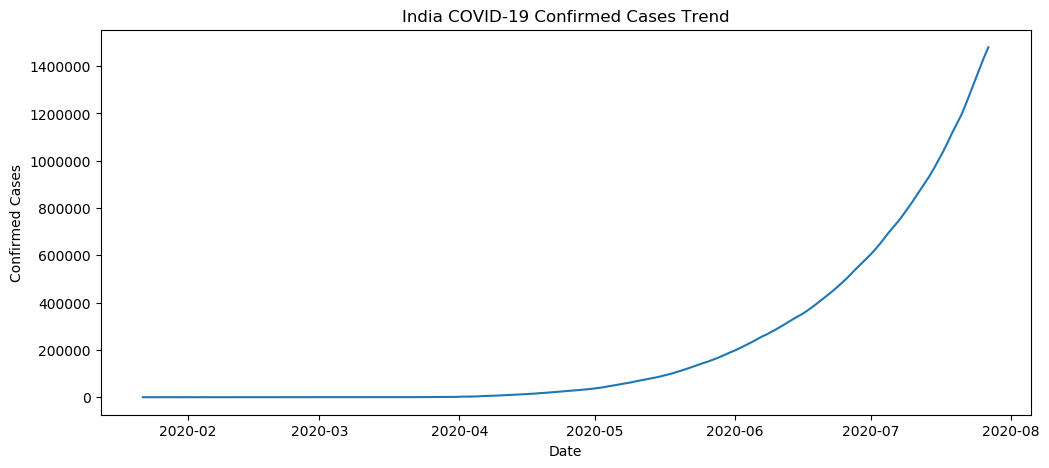

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(india["Date"], india["Confirmed"])

plt.title("India COVID-19 Confirmed Cases Trend")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

plt.savefig("visuals/chart1.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [18]:
india["rolling_cases"] = (
    india["Confirmed"]
    .rolling(7)
    .mean()
)

india.head()

c:\users\vijay krishna\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region,rolling_cases
129,Unknown,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia,NaN
390,Unknown,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia,NaN
651,Unknown,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia,NaN
912,Unknown,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia,NaN
1173,Unknown,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia,NaN


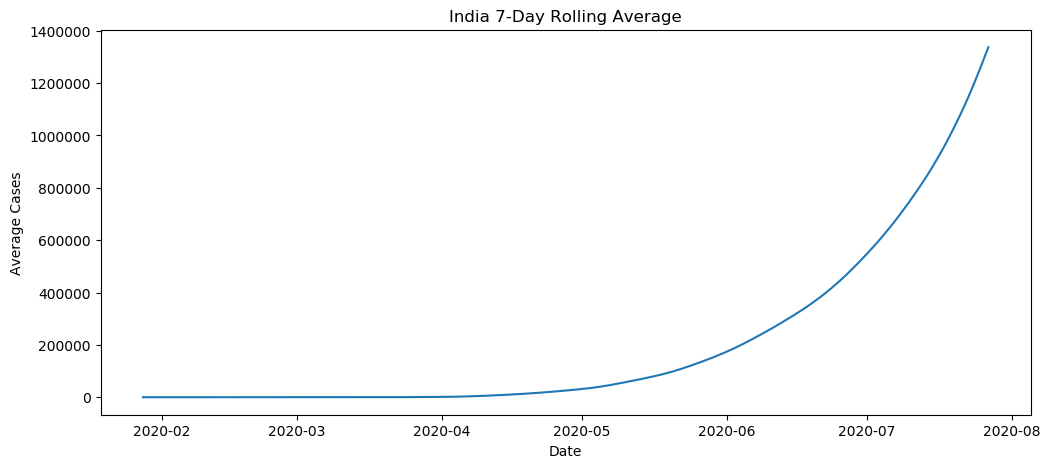

In [19]:
plt.figure(figsize=(12,5))

plt.plot(
    india["Date"],
    india["rolling_cases"]
)

plt.title("India 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Average Cases")

plt.savefig("visuals/chart2.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [20]:
usa = df[df["Country/Region"] == "US"]

In [21]:
china = df[df["Country/Region"] == "China"]

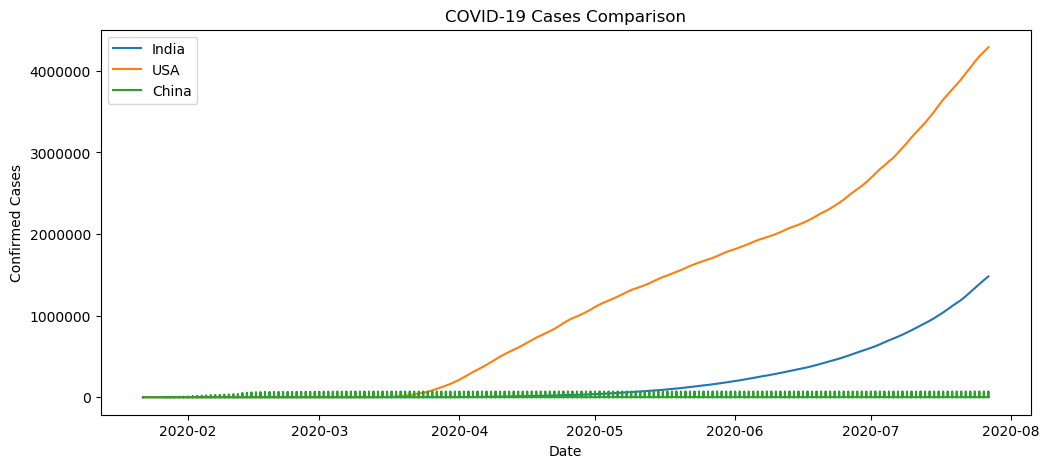

In [22]:
plt.figure(figsize=(12,5))

plt.plot(india["Date"], india["Confirmed"], label="India")
plt.plot(usa["Date"], usa["Confirmed"], label="USA")
plt.plot(china["Date"], china["Confirmed"], label="China")

plt.legend()

plt.title("COVID-19 Cases Comparison")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

plt.savefig("visuals/chart3.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

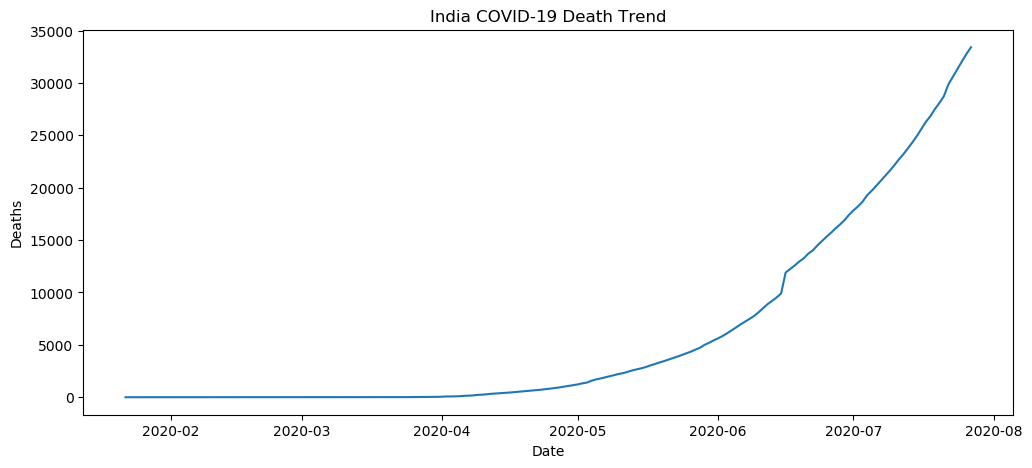

In [23]:
plt.figure(figsize=(12,5))

plt.plot(india["Date"], india["Deaths"])

plt.title("India COVID-19 Death Trend")
plt.xlabel("Date")
plt.ylabel("Deaths")

plt.savefig("visuals/chart4.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

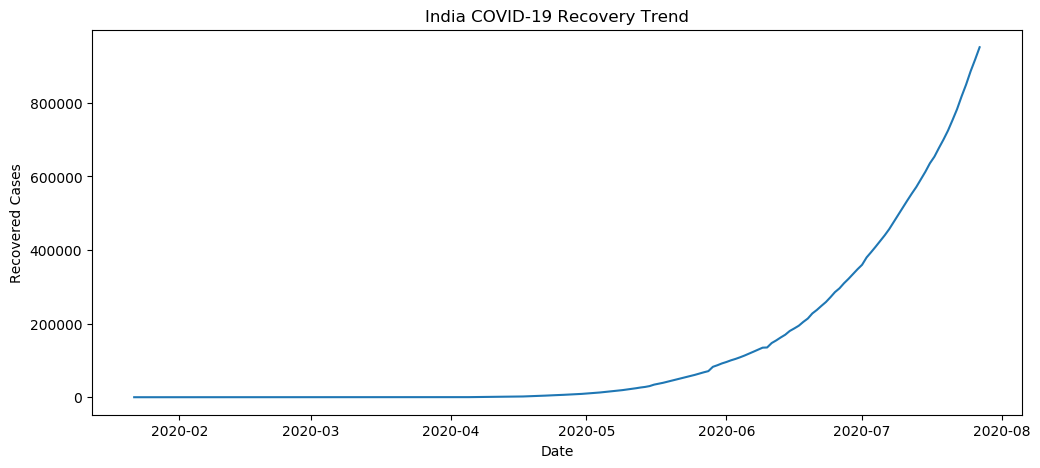

In [24]:
plt.figure(figsize=(12,5))

plt.plot(india["Date"], india["Recovered"])

plt.title("India COVID-19 Recovery Trend")
plt.xlabel("Date")
plt.ylabel("Recovered Cases")

plt.savefig("visuals/chart5.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

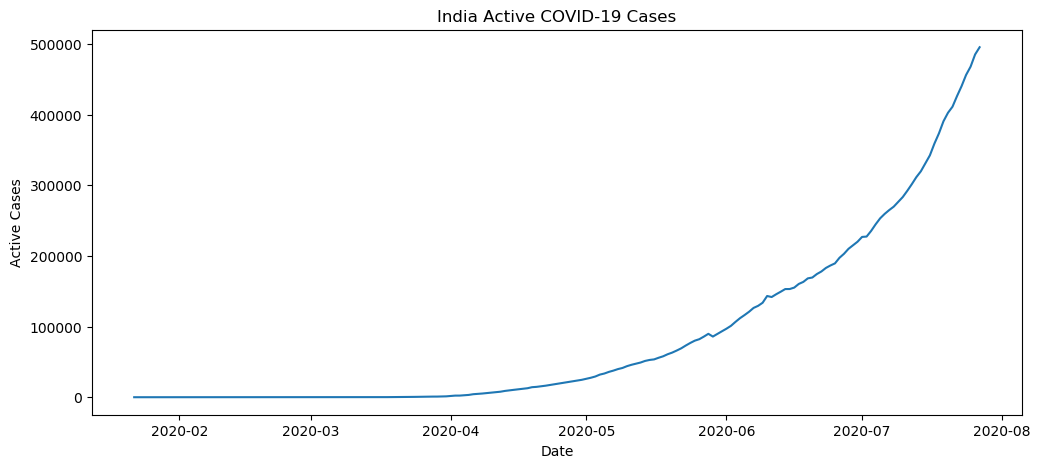

In [25]:
plt.figure(figsize=(12,5))

plt.plot(india["Date"], india["Active"])

plt.title("India Active COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Active Cases")

plt.savefig("visuals/chart6.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [26]:
import os

for file in sorted(os.listdir("visuals")):
    print(file, os.path.getsize("visuals/" + file))

chart1.png 116690
chart2.png 112920
chart3.png 139894
chart4.png 106391
chart5.png 105636
chart6.png 107139


# COVID-19 Analysis Insights

1. COVID-19 confirmed cases increased rapidly over time in India.

2. The 7-day rolling average showed smoother trends and reduced daily fluctuations.

3. The USA reported significantly higher confirmed cases than India and China during the observed period.

4. China's case growth stabilized earlier compared to India and the USA.

5. Recovery numbers increased steadily alongside confirmed cases.

6. Active cases rose sharply during outbreak peaks.

7. Death counts increased over time but remained much lower than total confirmed cases.

8. Rolling averages help identify long-term pandemic trends.

9. Country-wise comparisons highlight differences in outbreak progression.

10. Data visualization provides clear insights into pandemic patterns and public health trends.